In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.interpolate import CubicSpline
import matplotlib.colors as mcolors

from generate_colormap import *


from functools import partial
import starsim

from astropy.io import fits


import scipy.io as sio

from scipy.io import readsav

import jdcal as j 
from datetime import date

import pandas as pd


In [29]:
folder = '3_years'
data = readsav('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/DataSSI-SORCE.sav')
simu_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/{}/flux_test_mps.txt'.format(folder))
simu_phoenix = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/{}/flux_test_phoenix.txt'.format(folder))
# simu_stagger = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/flux_test_stagger.txt')

tsis_data_2018 = pd.read_csv('/home/sophie-stucki/starsim/starsim/SDO_input/tsis_tsi_24hr_2018.csv')
tsis_data_2021 = pd.read_csv('/home/sophie-stucki/starsim/starsim/SDO_input/tsis_tsi_24hr_2021.csv')



In [30]:
j.jd2gcal(data['time'][-1] - 2400000.5, 2400000.5)

(2020, 2, 25, 0.5)

In [42]:
t_tsi = []
t_ssi = []

data_ssi = []
data_tsi = []
wav_idx = (data['wavelengths'] >= 300) & (data['wavelengths'] <= 900)

wav = data['wavelengths'][wav_idx]

start_time = j.gcal2jd(2015,7,1)[1] + 2400000.5
end_time = j.gcal2jd(2018,7,1)[1] + 2400000.5

day_step = 7

day_tsis = tsis_data_2018['time (Julian Date)'] - start_time
# day_tsis = tsis_data_2021['time (Julian Date)'] - start_time


for i in range(len(data['time_ssi'])):
    if data['time_ssi'][i] >= start_time and data['time_ssi'][i] <= end_time:
        t_ssi.append(j.jd2gcal(2400000.5,data['time_ssi'][i]-2400000.5))

        data_ssi.append(data['ssi'][:,i][wav_idx])

for i in range(len(data['time'])):
    if data['time'][i] >= start_time and data['time'][i] <= end_time:
        t_tsi.append(j.jd2gcal(2400000.5,data['time'][i]-2400000.5))

        data_tsi.append(data['tsi'][i])


data_ssi = np.squeeze(data_ssi)
data_ssi *= 100**2 * 10000000


# data_ssi = np.sum(data_ssi / (1e-7 * wav) ,axis=1)

data_tsi = np.squeeze(data_tsi)
data_tsi *= 100**2 * 10000000

# Date de départ
start_date = date(t_tsi[0][0], t_tsi[0][1], t_tsi[0][2])

# Calcul du nombre de jours pour chaque date
days_tsi = [(date(y, m, d) - start_date).days + f for (y, m, d, f) in t_tsi]
# days_simu = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/maps_satire/time.txt')
days_simu = np.append(np.arange(57) * day_step, np.arange(58,157) * day_step)
# days_simu = np.arange(365)

# mask_tsis = tsis_data_2021['tsi_1au (W/m^2)']>0
mask_tsis = tsis_data_2018['tsi_1au (W/m^2)']>0


In [80]:
tsis_data_2018[mask_tsis]

,time (Julian Date),tsi_1au (W/m^2),avg_measurement_date (Julian Date)
0,2458130.0,1361.6518,2.458130e+06
1,2458131.0,1361.6579,2.458131e+06
2,2458132.0,1361.6219,2.458132e+06
9,2458139.0,1361.6497,2.458139e+06
11,2458141.0,1361.5861,2.458141e+06
...,...,...,...
167,2458297.0,1361.6680,2.458297e+06
168,2458298.0,1361.6404,2.458298e+06
169,2458299.0,1361.6213,2.458299e+06
170,2458300.0,1361.5940,2.458300e+06


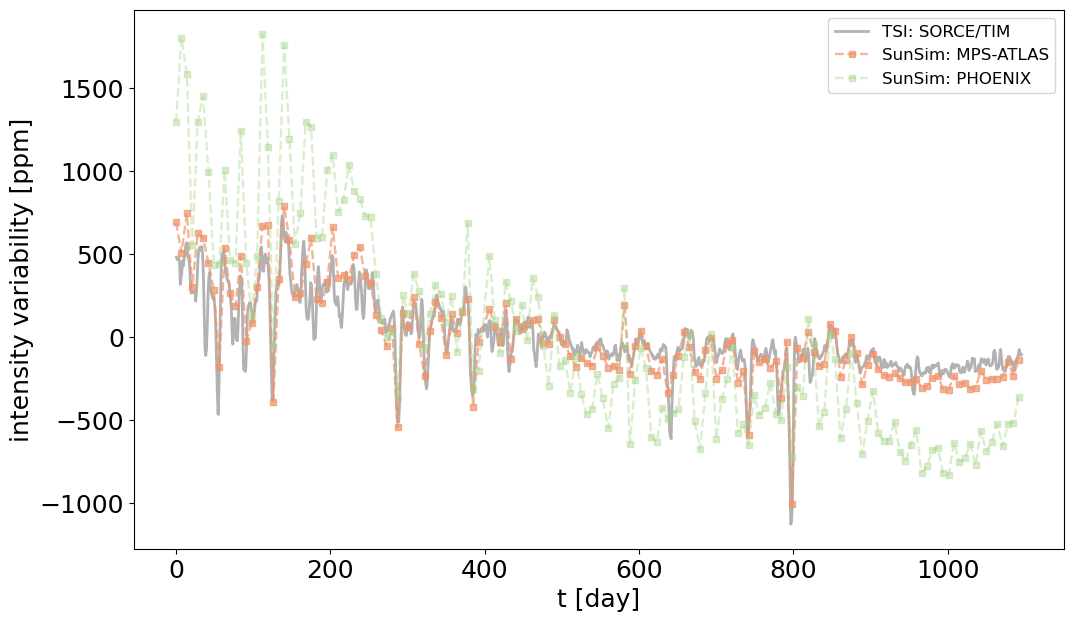

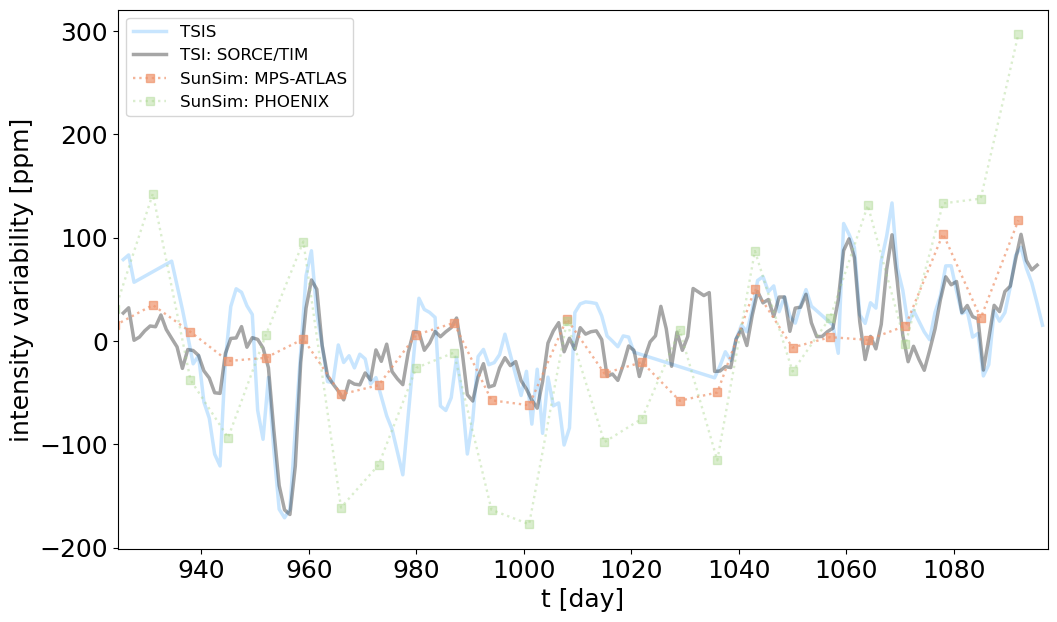

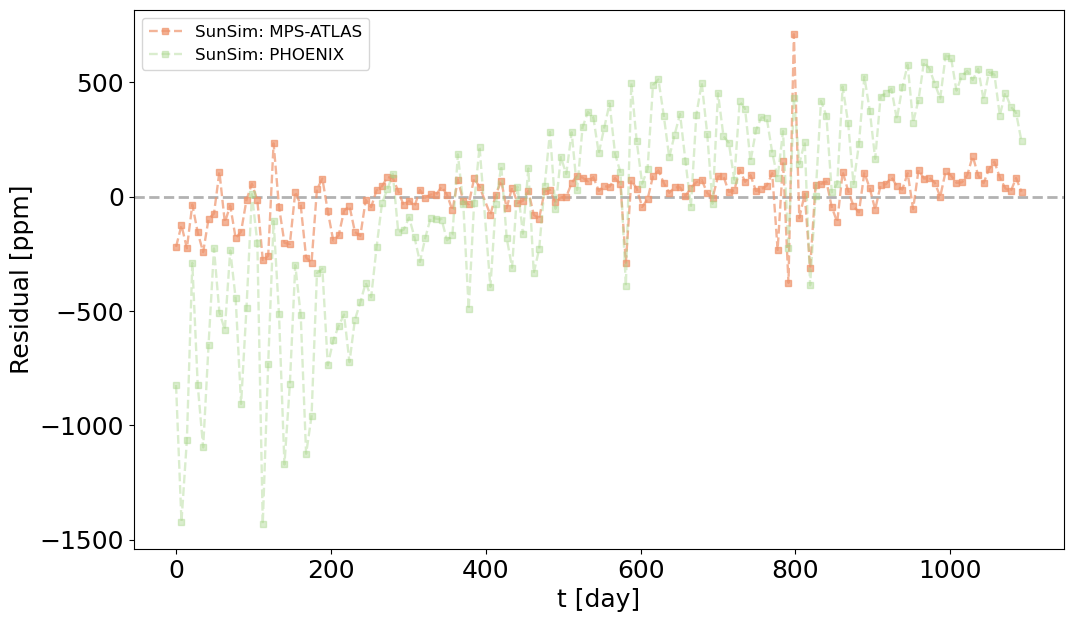

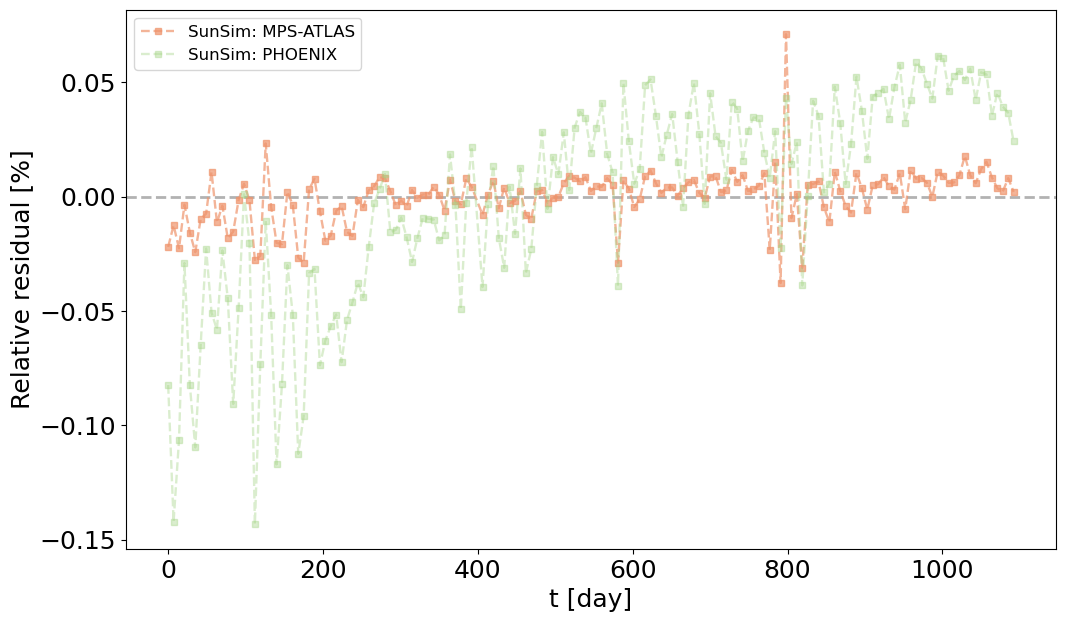

In [78]:
plt.rcParams['font.size'] = 18
plt.rcParams['figure.figsize'] = (12,7)

# plt.plot(day_tsis[mask_tsis], 1e6 * tsis_data_2018['tsi_1au (W/m^2)'][mask_tsis] / np.mean(tsis_data_2018['tsi_1au (W/m^2)'][mask_tsis]) - 1e6 , '-', label='TSIS', color="#76C0FD", alpha =0.3, linewidth=2)

plt.plot(days_tsi, 1e6 * data_tsi / np.mean(data_tsi) - 1e6 , '-', label='TSI: SORCE/TIM', color="#000000", alpha =0.3, linewidth=2)
plt.plot(days_simu, 1e6 * simu_mps / np.mean(simu_mps) - 1e6,'s--', markersize=5, linewidth=1.7, label = 'SunSim: MPS-ATLAS', color='#ef946c', alpha=0.7)
# plt.plot(days_simu, 1e6 * simu_stagger / np.mean(simu_stagger) - 1e6,'s-', markersize=4, linewidth=1.5, label = 'SunSim: STAGGER', color="#ce9ffa", alpha=0.7)
plt.plot(days_simu, 1e6 * simu_phoenix / np.mean(simu_phoenix) - 1e6,'s--', markersize=5, linewidth=1.7, label = 'SunSim: PHOENIX', color="#a4d485", alpha=0.4)

plt.legend(fontsize=12)
plt.xlabel('t [day]')

plt.ylabel('intensity variability [ppm]')
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/comparison_b.png',  dpi=300, bbox_inches='tight')

plt.show()

plt.plot(day_tsis[mask_tsis], 1e6 * tsis_data_2018['tsi_1au (W/m^2)'][mask_tsis] / np.mean(tsis_data_2018['tsi_1au (W/m^2)'][mask_tsis]) - 1e6 , '-', label='TSIS', color="#76C0FD", alpha =0.4, linewidth=2.5)

plt.plot(days_tsi[923:], 1e6 * data_tsi[923:] / np.mean(data_tsi[923:]) - 1e6 , '-', label='TSI: SORCE/TIM', color="#000000", alpha =0.35, linewidth=2.5)
plt.plot(days_simu[131:], 1e6 * simu_mps[131:] / np.mean(simu_mps[131:]) - 1e6,'s:', markersize=6, linewidth=1.7, label = 'SunSim: MPS-ATLAS', color='#ef946c', alpha=0.7)
plt.plot(days_simu[131:], 1e6 * simu_phoenix[131:] / np.mean(simu_phoenix[131:]) - 1e6,'s:', markersize=6, linewidth=1.7, label = 'SunSim: PHOENIX', color="#a4d485", alpha=0.4)

plt.legend(fontsize=12)
plt.xlabel('t [day]')
plt.xlim(day_tsis[0]-1, day_tsis[len(day_tsis)-1]+1)

plt.ylabel('intensity variability [ppm]')
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/comparison_tsis.png',  dpi=300, bbox_inches='tight')

plt.show()

plt.axhline(0, linestyle= '--', color="#000000", alpha =0.3, linewidth=2 )
plt.plot(days_simu, 1e6 * (data_tsi[days_simu] / np.mean(data_tsi[days_simu]) - simu_mps / np.mean(simu_mps)) ,'s--', markersize=5, linewidth=1.7, label = 'SunSim: MPS-ATLAS', color='#ef946c', alpha=0.7)
plt.plot(days_simu, 1e6 * (data_tsi[days_simu] / np.mean(data_tsi[days_simu]) - simu_phoenix / np.mean(simu_phoenix)),'s--', markersize=5, linewidth=1.7, label = 'SunSim: PHOENIX', color="#a4d485", alpha=0.4)

plt.legend(fontsize=12)
plt.xlabel('t [day]')

plt.ylabel('Residual [ppm]')
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/res_comparison_b.png',  dpi=300, bbox_inches='tight')

plt.show()

plt.axhline(0, linestyle= '--', color="#000000", alpha =0.3, linewidth=2 )
plt.plot(days_simu, 100 * (data_tsi[days_simu] / np.mean(data_tsi[days_simu]) - simu_mps / np.mean(simu_mps)) / (data_tsi[days_simu] / np.mean(data_tsi[days_simu])) ,'s--', markersize=5, linewidth=1.7, label = 'SunSim: MPS-ATLAS', color='#ef946c', alpha=0.7)
plt.plot(days_simu, 100 * (data_tsi[days_simu] / np.mean(data_tsi[days_simu]) - simu_phoenix / np.mean(simu_phoenix)) / (data_tsi[days_simu] / np.mean(data_tsi[days_simu])),'s--', markersize=5, linewidth=1.7, label = 'SunSim: PHOENIX', color="#a4d485", alpha=0.4)

plt.legend(fontsize=12)
plt.xlabel('t [day]')

plt.ylabel('Relative residual [%]')
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/rel_res_comparison_b.png',  dpi=300, bbox_inches='tight')

plt.show()

# # plt.plot(days_simu, 1e6 * simu_stagger / np.mean(simu_stagger) - 1e6,'s-', markersize=4, linewidth=1.5, label = 'SunSim: STAGGER', color="#ce9ffa", alpha=0.7)
# plt.plot(days_simu, 1e6 * simu_phoenix / np.mean(simu_phoenix) - 1e6,'s-', markersize=4, linewidth=1.5, label = 'SunSim: PHOENIX', color="#a4d485", alpha=0.5)

# plt.legend(fontsize=12)
# plt.xlabel('t [day]')
# plt.ylabel('intensity variability [ppm]')
# plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/comparison_stagger.png',  dpi=300, bbox_inches='tight')

# plt.show()

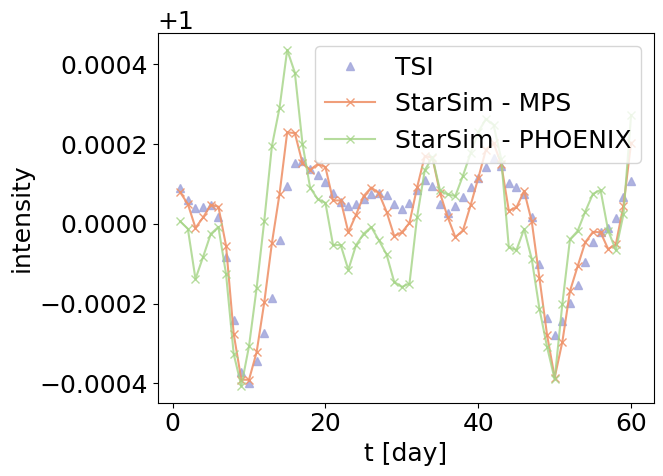

Text(0, 0.5, 'Models')

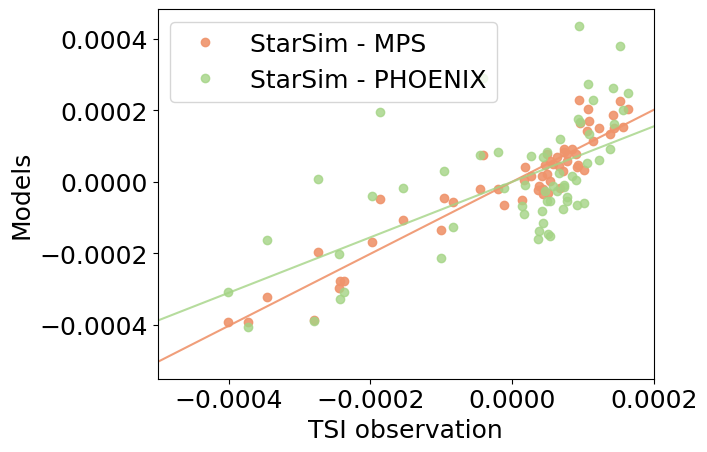

In [22]:
from scipy.interpolate import interp1d
from scipy.stats import linregress

# Example: t_obs, tsi_obs  -- time and TSI from observations
#          t_model, tsi_model  -- time and TSI from a model

# Interpolate model to observation times
interp_func = interp1d(days_tsi, data_tsi, kind='linear', bounds_error=False, fill_value='extrapolate')
days_simu_d = days_simu[1:-1]

tsi_model_interp = interp_func(days_simu_d)



# a4d485

plt.plot(days_simu_d, tsi_model_interp / np.mean(tsi_model_interp)  , '^', label='TSI', color='#a7abdd', alpha =0.9)
plt.plot(days_simu_d, simu_mps[1:-1] / np.mean(simu_mps[1:-1]) ,'x-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9)
plt.plot(days_simu_d, simu_phoenix[1:-1] / np.mean(simu_phoenix[1:-1]) ,'x-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.8)

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('intensity')
plt.show()

detrended_tsi = (tsi_model_interp - np.mean(tsi_model_interp)) / np.mean(tsi_model_interp)
detrended_mps = (simu_mps[1:-1] - np.mean(simu_mps[1:-1])) / np.mean(simu_mps[1:-1])
detrended_pho = (simu_phoenix[1:-1] - np.mean(simu_phoenix[1:-1])) / np.mean(simu_phoenix[1:-1])
x = np.linspace(-0.0005, 0.0002)

slope_mps, intercept_mps, r_value_mps, p_value_mps, std_err_mps = linregress(detrended_tsi, detrended_mps)
slope_pho, intercept_pho, r_value_pho, p_value_pho, std_err_pho = linregress(detrended_tsi, detrended_pho)


plt.plot(detrended_tsi, detrended_mps ,'o', label = 'StarSim - MPS', color='#ef946c', alpha=0.9)
plt.plot(detrended_tsi, detrended_pho ,'o', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.8)
plt.plot(x, slope_mps * x + intercept_mps, color='#ef946c', alpha=0.9)
plt.plot(x, slope_pho * x + intercept_pho, color='#a4d485', alpha=0.8)
plt.xlim(-0.0005, 0.0002)
plt.legend()
plt.xlabel('TSI observation')
plt.ylabel('Models')


In [23]:
print('MPS:', slope_mps, r_value_mps)
print('PHOENIX:', slope_pho, r_value_pho)


MPS: 1.0072117372490745 0.9380112703101595
PHOENIX: 0.7759918775438231 0.6325907236705477


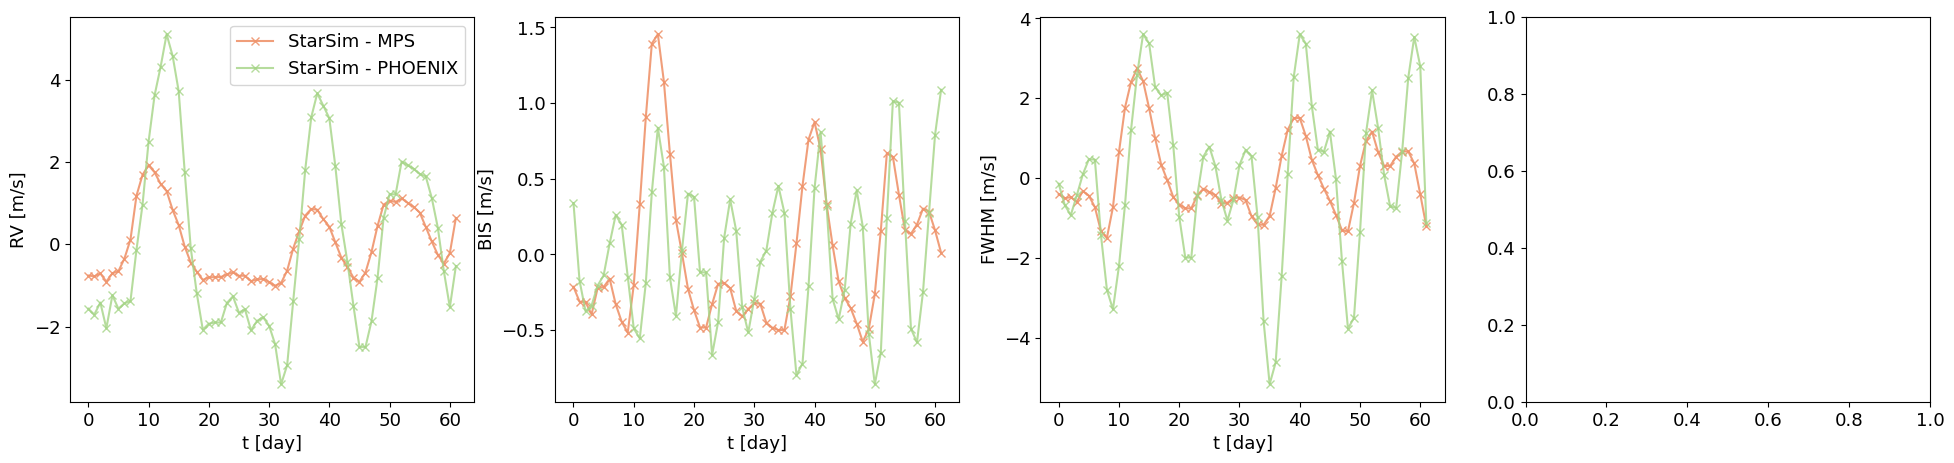

In [24]:
rv_simu_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/rv_test_mps.txt')
rv_simu_phoenix = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/rv_test_phoenix.txt')

bis_simu_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/bis_test_mps.txt')
bis_simu_phoenix = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/bis_test_phoenix.txt')

fwhm_simu_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/fwhm_test_mps.txt')
fwhm_simu_phoenix = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/fwhm_test_phoenix.txt')

plt.rcParams['font.size'] = 13


fig, axs = plt.subplots(1,4, figsize=(24,5))


axs[0].plot(days_simu, rv_simu_mps - np.mean(rv_simu_mps) ,'x-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9)
axs[0].plot(days_simu, rv_simu_phoenix - np.mean(rv_simu_phoenix),'x-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.8)
axs[0].set_xlabel('t [day]')
axs[0].set_ylabel('RV [m/s]')


axs[1].plot(days_simu, bis_simu_mps - np.mean(bis_simu_mps) ,'x-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9)
axs[1].plot(days_simu, bis_simu_phoenix - np.mean(bis_simu_phoenix),'x-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.8)
axs[1].set_xlabel('t [day]')
axs[1].set_ylabel('BIS [m/s]')


axs[2].plot(days_simu, fwhm_simu_mps - np.mean(fwhm_simu_mps) ,'x-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9)
axs[2].plot(days_simu, fwhm_simu_phoenix - np.mean(fwhm_simu_phoenix),'x-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.8)
axs[2].set_xlabel('t [day]')
axs[2].set_ylabel('FWHM [m/s]')

axs[0].legend()
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/comparison_spec.pdf',  dpi=300, bbox_inches='tight')

plt.show()

range(0, 62)
[0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5, 22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5, 32.5, 33.5, 34.5, 35.5, 36.5, 37.5, 38.5, 39.5, 40.5, 41.5, 42.5, 44.5, 45.5, 47.5, 48.5, 49.5, 50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57.5, 58.5, 59.5, 60.5, 61.5]


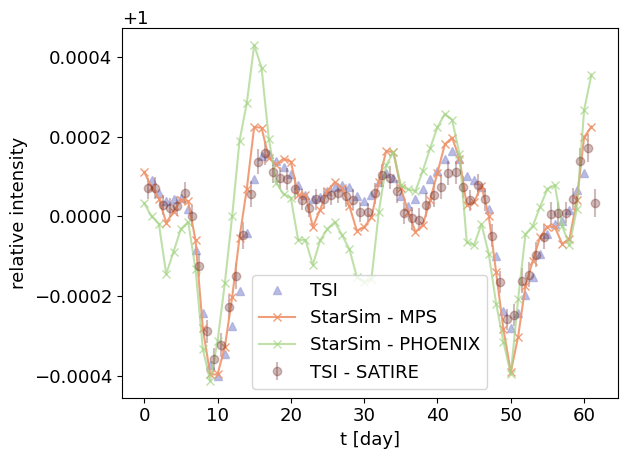

In [25]:
data_tsi_satire = np.loadtxt('/home/sophie-stucki/Documents/starsim_simulations/nina_spec/SATIRE-S_TSI_latest.txt')


t_satire = []
data_satire = []
err_d = []
err_u = []

for i in range(len(data_tsi_satire[:,0])):
    if data_tsi_satire[i,0] >= start_time and data_tsi_satire[i,0] <= end_time:
        t_satire.append(j.jd2gcal(2400000.5, data_tsi_satire[i,0]-2400000.5))

        data_satire.append(data_tsi_satire[i,1])
        err_d.append(data_tsi_satire[i,2])
        err_u.append(data_tsi_satire[i,2])


days_satire = [(date(y, m, d) - start_date).days + f for (y, m, d, f) in t_satire]



plt.plot(days_simu_d, tsi_model_interp / np.mean(tsi_model_interp)  , '^', label='TSI', color='#a7abdd', alpha =0.8)
plt.errorbar(days_satire, data_satire / np.mean(data_satire)  , yerr=np.array([(np.array(data_satire) - np.array(err_d)) / np.mean(data_satire), (np.array(data_satire) - np.array(err_u)) / np.mean(data_satire)]), label='TSI - SATIRE', marker='o', linestyle='', color='#661F1C', alpha =0.3)
plt.plot(days_simu, simu_mps / np.mean(simu_mps) ,'x-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9)
plt.plot(days_simu, simu_phoenix / np.mean(simu_phoenix) ,'x-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.7)

plt.legend()
plt.xlabel('t [day]')
plt.ylabel('relative intensity')
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/comparison.png',  dpi=300, bbox_inches='tight')

print(days_simu)
print(days_tsi)

In [26]:
 np.array(err_d) - np.array(data_satire)

array([-0.0367, -0.0361, -0.0341, -0.0338, -0.0341, -0.0364, -0.0377,
       -0.0387, -0.0384, -0.0396, -0.0407, -0.0416, -0.0439, -0.0456,
       -0.0444, -0.044 , -0.0413, -0.0384, -0.0378, -0.0377, -0.0362,
       -0.0348, -0.0337, -0.0346, -0.0346, -0.0352, -0.0356, -0.0354,
       -0.035 , -0.0332, -0.033 , -0.035 , -0.0391, -0.0406, -0.0405,
       -0.039 , -0.0391, -0.0391, -0.0407, -0.0413, -0.0409, -0.0411,
       -0.0401, -0.0369, -0.0349, -0.0371, -0.0386, -0.0388, -0.0378,
       -0.0361, -0.0372, -0.0417, -0.0418, -0.0429, -0.0432, -0.0417,
       -0.0383, -0.0366, -0.0376, -0.0429, -0.0478, -0.0486])